In [2]:
import os
import gc
import shutil
from pathlib import Path
import pandas as pd
from google.colab import drive

# Mount Google Drive

print("1. Mounting Google Drive...")
drive.mount('/content/drive', force_remount=False)

MY_DRIVE_ROOT = Path('/content/drive/MyDrive')
LOCAL_TARGET_DIR = Path('/content/nba_final_data')
LOCAL_TARGET_DIR.mkdir(parents=True, exist_ok=True)

TARGET_KEYS = [
    'game_odds',
    'games_index',
    'games_schedule',
    'play_by_play',
    'player_boxscores',
    'team_boxscores'
]


# Locate NBA csv Files

print("\n2. Scanning Google Drive for NBA dataset CSV files...")

file_map = {}
for root, _, files in os.walk(MY_DRIVE_ROOT):
    for f in files:
        if f.lower().endswith('.csv'):
            full_path = Path(root) / f
            f_clean = f.lower().replace('-', '_').replace(' ', '_')
            for key in TARGET_KEYS:
                if key not in file_map and key in f_clean:
                    file_map[key] = full_path
                    print(f"  ✔ Found '{key}' -> {full_path}")


# Convert csv to Parquet (Memory Saver)

print("\n3. Converting CSVs to compressed Parquet format to save RAM...")

parquet_map = {}
for key, drive_path in file_map.items():
    pq_path = LOCAL_TARGET_DIR / f"{key}.parquet"
    parquet_map[key] = pq_path

    if not pq_path.exists():
        # Stream CSV in chunks to avoid spiking RAM during conversion
        chunks = []
        for chunk in pd.read_csv(
            drive_path,
            chunksize=100000,
            low_memory=False,
            on_bad_lines='skip',
            engine='c'
        ):
            chunks.append(chunk)

        df_temp = pd.concat(chunks, ignore_index=True)
        # Downcast floats/ints where possible to minimize memory footprint
        df_temp.to_parquet(pq_path, engine='pyarrow', compression='snappy')
        del df_temp, chunks
        gc.collect()

print("  ✔ Parquet conversion complete.")


# Load & Merge Game-Level Master

print("\n4. Building Game-Level Master DataFrame...")

# Load only necessary datasets and drop heavy unused columns
schedule_df = pd.read_parquet(parquet_map['games_schedule'])
team_box_df = pd.read_parquet(parquet_map['team_boxscores'])

if 'game_odds' in parquet_map:
    odds_df = pd.read_parquet(parquet_map['game_odds']).drop_duplicates(subset=['game_id'], keep='first')
else:
    odds_df = None

home_col = 'is_home' if 'is_home' in team_box_df.columns else ('location' if 'location' in team_box_df.columns else None)

if home_col:
    home_team = team_box_df[team_box_df[home_col] == 1].add_prefix('home_')
    away_team = team_box_df[team_box_df[home_col] == 0].add_prefix('away_')

    game_level_df = (
        schedule_df
        .merge(home_team, left_on='game_id', right_on='home_game_id', how='left')
        .merge(away_team, left_on='game_id', right_on='away_game_id', how='left')
    )
    del home_team, away_team, team_box_df
    gc.collect()
else:
    game_level_df = schedule_df.merge(team_box_df, on='game_id', how='left')
    del team_box_df
    gc.collect()

if odds_df is not None and 'game_id' in odds_df.columns:
    game_level_df = game_level_df.merge(odds_clean if 'odds_clean' in locals() else odds_df, on='game_id', how='left', suffixes=('', '_odds'))

game_level_df.to_parquet(LOCAL_TARGET_DIR / 'master_game_level.parquet', compression='snappy')
print(f"  ✔ Game-Level Master saved ({game_level_df.shape[0]:,} rows × {game_level_df.shape[1]} cols)")

# Free memory before starting player-level processing
del game_level_df, schedule_df
gc.collect()


# Load & Merge Player-Level Master

print("\n5. Building Player-Level Master DataFrame...")

if 'player_boxscores' in parquet_map:
    player_df = pd.read_parquet(parquet_map['player_boxscores'])
    schedule_df = pd.read_parquet(parquet_map['games_schedule'])

    player_level_df = player_df.merge(schedule_df, on='game_id', how='left', suffixes=('', '_sched'))
    del player_df, schedule_df
    gc.collect()

    if odds_df is not None and 'game_id' in odds_df.columns:
        player_level_df = player_level_df.merge(odds_df, on='game_id', how='left', suffixes=('', '_odds'))
        del odds_df
        gc.collect()

    player_level_df.to_parquet(LOCAL_TARGET_DIR / 'master_player_level.parquet', compression='snappy')
    print(f"  ✔ Player-Level Master saved ({player_level_df.shape[0]:,} rows × {player_level_df.shape[1]} cols)")

print("\n✔ Processing complete! Run `pd.read_parquet('/content/nba_final_data/master_game_level.parquet')` to load when needed.")

1. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2. Scanning Google Drive for NBA dataset CSV files...
  ✔ Found 'game_odds' -> /content/drive/MyDrive/Emilia’s photos (Summer ball + last salvos)/NBA data/game_odds.csv
  ✔ Found 'games_schedule' -> /content/drive/MyDrive/Emilia’s photos (Summer ball + last salvos)/NBA data/games_schedule.csv
  ✔ Found 'games_index' -> /content/drive/MyDrive/Emilia’s photos (Summer ball + last salvos)/NBA data/games_index.csv
  ✔ Found 'play_by_play' -> /content/drive/MyDrive/Emilia’s photos (Summer ball + last salvos)/NBA data/play_by_play.csv
  ✔ Found 'player_boxscores' -> /content/drive/MyDrive/Emilia’s photos (Summer ball + last salvos)/NBA data/player_boxscores.csv
  ✔ Found 'team_boxscores' -> /content/drive/MyDrive/Emilia’s photos (Summer ball + last salvos)/NBA data/team_boxscores.csv

3. Converting CSVs to compressed Parquet format to sa

In [3]:
import numpy as np
import openpyxl
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from pathlib import Path


# Load Data & Calculate ESPN Fantasy Points

print("1. Loading player-level box scores and calculating ESPN Points...")
df = pd.read_parquet("/content/nba_final_data/master_player_level.parquet")

# Standard ESPN Points Scoring System
df["espn_fpts"] = (
    df["pts"] * 1.0
    + df["reb"] * 1.0
    + df["ast"] * 2.0
    + df["stl"] * 4.0
    + df["blk"] * 4.0
    - df["tov"] * 2.0
    + df.get("fg3m", 0) * 1.0
)

# Parse season year from game_date if explicit season column is missing
if "season" not in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"])
    df["season"] = df["game_date"].apply(
        lambda d: d.year if d.month >= 10 else d.year - 1
    )

# Extract mode position per player
if "position" in df.columns:
    pos_col = "position"
elif "player_position" in df.columns:
    pos_col = "player_position"
else:
    pos_col = None

if pos_col:
    player_positions = (
        df.groupby("player_name")[pos_col]
        .agg(lambda x: x.mode().iloc[0] if not x.empty else "UTIL")
        .reset_index()
        .rename(columns={pos_col: "position"})
    )
else:
    player_positions = pd.DataFrame(
        {"player_name": df["player_name"].unique(), "position": "UTIL"}
    )

pos_map = {
    "G": "PG",
    "F": "SF",
    "FC": "C",
    "GF": "SG",
    "PG": "PG",
    "SG": "SG",
    "SF": "SF",
    "PF": "PF",
    "C": "C",
}
player_positions["position"] = player_positions["position"].map(
    lambda x: pos_map.get(str(x).upper(), "UTIL")
)

# Aggregate Season-Level Metrics

print("2. Aggregating seasonal player metrics...")
df_filtered = df[df["min"] > 0].copy()

season_agg = (
    df_filtered.groupby(["player_id", "player_name", "season"])
    .agg(
        games_played=("game_id", "count"),
        mpg=("min", "mean"),
        fpts_pg=("espn_fpts", "mean"),
        fpts_per_min=(
            "espn_fpts",
            lambda x: x.sum() / df_filtered.loc[x.index, "min"].sum(),
        ),
        pts_pg=("pts", "mean"),
        reb_pg=("reb", "mean"),
        ast_pg=("ast", "mean"),
        stl_pg=("stl", "mean"),
        blk_pg=("blk", "mean"),
        tov_pg=("tov", "mean"),
        fg_pct=(
            "fgm",
            lambda x: x.sum() / max(df_filtered.loc[x.index, "fga"].sum(), 1),
        ),
        ft_pct=(
            "ftm",
            lambda x: x.sum() / max(df_filtered.loc[x.index, "fta"].sum(), 1),
        ),
    )
    .reset_index()
)

season_agg = season_agg[season_agg["games_played"] >= 10].sort_values(
    ["player_id", "season"]
)

# Build Lagged Feature Matrix (t, t-1, t-2 -> t+1)

print("3. Engineering multi-year lagged features...")

feature_cols = [
    "games_played",
    "mpg",
    "fpts_pg",
    "fpts_per_min",
    "pts_pg",
    "reb_pg",
    "ast_pg",
    "stl_pg",
    "blk_pg",
    "tov_pg",
    "fg_pct",
    "ft_pct",
]

records = []
players = season_agg["player_id"].unique()

for p_id in players:
    p_df = season_agg[season_agg["player_id"] == p_id].sort_values("season")
    p_name = p_df["player_name"].iloc[0]
    seasons = p_df["season"].values

    for i in range(len(seasons)):
        curr_season = seasons[i]
        target_row = p_df[p_df["season"] == curr_season + 1]

        row_t = p_df[p_df["season"] == curr_season]
        row_t1 = p_df[p_df["season"] == curr_season - 1]
        row_t2 = p_df[p_df["season"] == curr_season - 2]

        if row_t.empty:
            continue

        record = {
            "player_id": p_id,
            "player_name": p_name,
            "target_season": curr_season + 1,
            "target_fpts_pg": target_row["fpts_pg"].values[0]
            if not target_row.empty
            else np.nan,
        }

        for col in feature_cols:
            record[f"{col}_t"] = row_t[col].values[0]
            record[f"{col}_t1"] = (
                row_t1[col].values[0] if not row_t1.empty else np.nan
            )
            record[f"{col}_t2"] = (
                row_t2[col].values[0] if not row_t2.empty else np.nan
            )

        if not row_t1.empty:
            record["fpts_trend_t_t1"] = record["fpts_pg_t"] - record["fpts_pg_t1"]
            record["mpg_trend_t_t1"] = record["mpg_t"] - record["mpg_t1"]
        else:
            record["fpts_trend_t_t1"] = np.nan
            record["mpg_trend_t_t1"] = np.nan

        records.append(record)

lagged_df = pd.DataFrame(records)


# Train XGBoost & Generate 2026/27 Projections

print("4. Training XGBoost Model...")

train_val_df = lagged_df.dropna(subset=["target_fpts_pg"]).copy()
pred_2026_df = lagged_df[lagged_df["target_season"] == 2026].copy()

model_features = [
    c
    for c in train_val_df.columns
    if c not in ["player_id", "player_name", "target_season", "target_fpts_pg"]
]

X = train_val_df[model_features]
y = train_val_df["target_fpts_pg"]

val_mask = train_val_df["target_season"] == 2025
X_train, y_train = X[~val_mask], y[~val_mask]
X_val, y_val = X[val_mask], y[val_mask]

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

val_preds = model.predict(X_val)
print(f"  ✔ Validation RMSE (Predicting 2025/26): {np.sqrt(mean_squared_error(y_val, val_preds)):.2f} FPTS/G")

X_2026 = pred_2026_df[model_features]
pred_2026_df["proj_2026_fpts_pg"] = model.predict(X_2026)

projections = pred_2026_df[
    ["player_name", "proj_2026_fpts_pg", "fpts_pg_t", "games_played_t"]
].rename(
    columns={"fpts_pg_t": "last_season_fpts", "games_played_t": "last_season_gp"}
)

projections = projections.merge(player_positions, on="player_name", how="left")
projections["position"] = projections["position"].fillna("UTIL")


# Calculate 16-Team ESPN VORP

print("5. Computing 16-team positional replacement baselines & VORP...")

NUM_TEAMS = 16
TOTAL_STARTERS = 10 * NUM_TEAMS  # 160 total starters

pos_demand = {
    "PG": 1 * NUM_TEAMS,
    "SG": 1 * NUM_TEAMS,
    "SF": 1 * NUM_TEAMS,
    "PF": 1 * NUM_TEAMS,
    "C": 1 * NUM_TEAMS,
}

replacement_baselines = {}
for pos in ["PG", "SG", "SF", "PF", "C"]:
    pos_players = projections[projections["position"] == pos].sort_values(
        "proj_2026_fpts_pg", ascending=False
    )
    cutoff = pos_demand[pos]
    replacement_baselines[pos] = (
        pos_players.iloc[cutoff - 1]["proj_2026_fpts_pg"]
        if len(pos_players) >= cutoff
        else pos_players["proj_2026_fpts_pg"].min()
    )

sorted_all = projections.sort_values("proj_2026_fpts_pg", ascending=False)
replacement_baselines["UTIL"] = (
    sorted_all.iloc[TOTAL_STARTERS - 1]["proj_2026_fpts_pg"]
    if len(sorted_all) >= TOTAL_STARTERS
    else 15.0
)

projections["vorp"] = projections.apply(
    lambda r: r["proj_2026_fpts_pg"]
    - replacement_baselines.get(r["position"], replacement_baselines["UTIL"]),
    axis=1,
)

# Statistical Tier Clustering (K-MEANS)

print("6. Clustering VORP into 8 draft tiers...")

draft_pool = (
    projections.sort_values("vorp", ascending=False)
    .head(160)
    .reset_index(drop=True)
)
vorp_vals = draft_pool["vorp"].values.reshape(-1, 1)

N_TIERS = 8
kmeans = KMeans(n_clusters=N_TIERS, random_state=42, n_init=20)
draft_pool["raw_cluster"] = kmeans.fit_predict(vorp_vals)

cluster_means = (
    draft_pool.groupby("raw_cluster")["vorp"].mean().sort_values(ascending=False)
)
cluster_to_tier = {
    c_id: t + 1 for t, c_id in enumerate(cluster_means.index)
}
draft_pool["tier"] = draft_pool["raw_cluster"].map(cluster_to_tier)

draft_pool = draft_pool.sort_values(
    ["tier", "vorp"], ascending=[True, False]
).reset_index(drop=True)
draft_pool.index += 1  # 1-indexed Overall Rank

# Export To Styled Openpyxl Excel Sheet

print("7. Exporting styled Excel sheet...")

excel_df = draft_pool[
    [
        "tier",
        "player_name",
        "position",
        "proj_2026_fpts_pg",
        "vorp",
        "last_season_fpts",
        "last_season_gp",
    ]
].copy()

excel_df.insert(0, "Overall_Rank", excel_df.index)
excel_df.insert(1, "Drafted", "NO")
excel_df.columns = [
    "Overall Rank",
    "Drafted?",
    "Tier",
    "Player Name",
    "Position",
    "Proj FPTS/G",
    "VORP",
    "2025 FPTS/G",
    "2025 GP",
]

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "2026-27 ESPN Fantasy Board"
ws.views.sheetView[0].showGridLines = True

NAVY_HEADER_FILL = PatternFill(
    start_color="1B365D", end_color="1B365D", fill_type="solid"
)
WHITE_BOLD_FONT = Font(name="Segoe UI", size=11, bold=True, color="FFFFFF")
REGULAR_FONT = Font(name="Segoe UI", size=10)
BOLD_FONT = Font(name="Segoe UI", size=10, bold=True)

TIER_COLORS = {
    1: "003F5C",
    2: "2F4B7C",
    3: "665191",
    4: "A05195",
    5: "D45087",
    6: "F95D6A",
    7: "FF7C43",
    8: "FFA600",
}
THIN_BORDER = Border(
    left=Side(style="thin", color="D3D3D3"),
    right=Side(style="thin", color="D3D3D3"),
    top=Side(style="thin", color="D3D3D3"),
    bottom=Side(style="thin", color="D3D3D3"),
)

# Banner Header
ws.merge_cells("A1:I1")
title_cell = ws["A1"]
title_cell.value = "16-TEAM ESPN FANTASY BASKETBALL DRAFT BOARD (2026/27)"
title_cell.font = Font(name="Segoe UI", size=14, bold=True, color="FFFFFF")
title_cell.fill = NAVY_HEADER_FILL
title_cell.alignment = Alignment(horizontal="center", vertical="center")
ws.row_dimensions[1].height = 35

ws.append([])  # Blank Row 2

headers = list(excel_df.columns)
for col_num, header_title in enumerate(headers, 1):
    cell = ws.cell(row=3, column=col_num, value=header_title)
    cell.font = WHITE_BOLD_FONT
    cell.fill = NAVY_HEADER_FILL
    cell.alignment = Alignment(horizontal="center", vertical="center")
    cell.border = THIN_BORDER
ws.row_dimensions[3].height = 25

current_row = 4
current_tier = None

for _, row_data in excel_df.iterrows():
    row_tier = row_data["Tier"]

    if row_tier != current_tier:
        current_tier = row_tier
        ws.merge_cells(
            start_row=current_row,
            start_column=1,
            end_row=current_row,
            end_column=len(headers),
        )

        tier_cell = ws.cell(row=current_row, column=1)
        tier_cell.value = f"--- TIER {current_tier} ---"
        tier_cell.font = Font(
            name="Segoe UI", size=11, bold=True, color="FFFFFF"
        )

        fill_color = TIER_COLORS.get(current_tier, "555555")
        tier_cell.fill = PatternFill(
            start_color=fill_color, end_color=fill_color, fill_type="solid"
        )
        tier_cell.alignment = Alignment(horizontal="center", vertical="center")
        ws.row_dimensions[current_row].height = 22
        current_row += 1

    for col_idx, value in enumerate(row_data, 1):
        cell = ws.cell(row=current_row, column=col_idx, value=value)
        cell.font = REGULAR_FONT
        cell.border = THIN_BORDER

        if col_idx in [1, 3, 9]:
            cell.alignment = Alignment(horizontal="center", vertical="center")
            if col_idx != 2:
                cell.number_format = "#,##0"
        elif col_idx == 2:
            cell.alignment = Alignment(horizontal="center", vertical="center")
            cell.font = BOLD_FONT
        elif col_idx in [4, 5]:
            cell.alignment = Alignment(horizontal="left", vertical="center")
        elif col_idx in [6, 8]:
            cell.alignment = Alignment(horizontal="right", vertical="center")
            cell.number_format = "0.0"
        elif col_idx == 7:
            cell.alignment = Alignment(horizontal="right", vertical="center")
            cell.number_format = "+0.0;-0.0;0.0"
            cell.font = BOLD_FONT

    ws.row_dimensions[current_row].height = 18
    current_row += 1

ws.freeze_panes = "A4"

# Set column widths
ws.column_dimensions["A"].width = 14
ws.column_dimensions["B"].width = 12
ws.column_dimensions["C"].width = 10
ws.column_dimensions["D"].width = 26
ws.column_dimensions["E"].width = 12
ws.column_dimensions["F"].width = 14
ws.column_dimensions["G"].width = 12
ws.column_dimensions["H"].width = 14
ws.column_dimensions["I"].width = 12

output_path = "ESPN_16Team_Fantasy_Draft_Board_2026.xlsx"
wb.save(output_path)
print(
    f"\n✔ Complete execution finished! Output saved to: {output_path}"
)


1. Loading player-level box scores and calculating ESPN Points...
2. Aggregating seasonal player metrics...
3. Engineering multi-year lagged features...
4. Training XGBoost Model...
  ✔ Validation RMSE (Predicting 2025/26): 6.21 FPTS/G
5. Computing 16-team positional replacement baselines & VORP...
6. Clustering VORP into 8 draft tiers...
7. Exporting styled Excel sheet...

✔ Complete execution finished! Output saved to: ESPN_16Team_Fantasy_Draft_Board_2026.xlsx


/tmp/ipykernel_7131/780236150.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


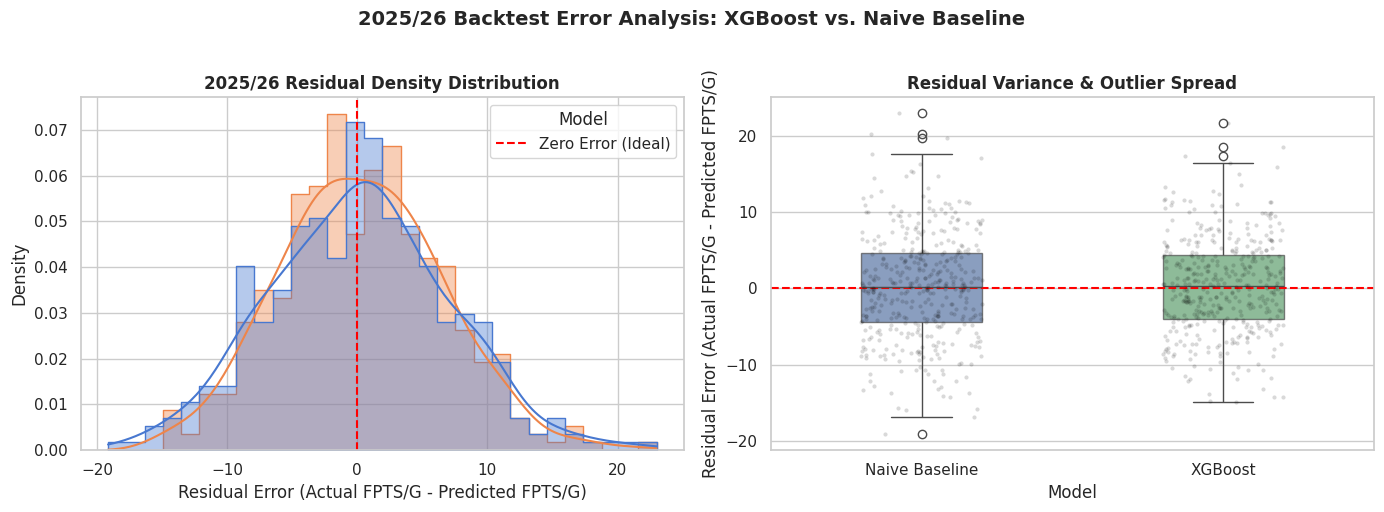

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Residuals & Prepare Tidy Dataframe

# Residual = Actual FPTS/G - Predicted FPTS/G
residuals_xgb = backtest_df["actual_2025_fpts_pg"] - backtest_df["proj_2025_fpts_pg"]
residuals_base = backtest_df["actual_2025_fpts_pg"] - backtest_df["naive_baseline_2024"]

df_residuals = pd.DataFrame({
    'Residual Error': np.concatenate([residuals_base, residuals_xgb]),
    'Model': ['Naive Baseline'] * len(residuals_base) + ['XGBoost'] * len(residuals_xgb)
})

# Plot Residual Error Distributions

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Density Histogram + Kernel Density Estimation (KDE)
sns.histplot(
    data=df_residuals,
    x='Residual Error',
    hue='Model',
    kde=True,
    stat='density',
    common_norm=False,
    element='step',
    bins=30,
    alpha=0.4,
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error (Ideal)')
axes[0].set_title('2025/26 Residual Density Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual Error (Actual FPTS/G - Predicted FPTS/G)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Model')

# Subplot 2: Boxplot & Scatter Overlay for Error Variance & Outliers
sns.boxplot(
    data=df_residuals,
    x='Model',
    y='Residual Error',
    palette=['#4C72B0', '#55A868'],
    width=0.4,
    boxprops=dict(alpha=0.7),
    ax=axes[1]
)
sns.stripplot(
    data=df_residuals,
    x='Model',
    y='Residual Error',
    color='black',
    alpha=0.15,
    jitter=0.2,
    size=3,
    ax=axes[1]
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Variance & Outlier Spread', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Residual Error (Actual FPTS/G - Predicted FPTS/G)')

plt.suptitle('2025/26 Backtest Error Analysis: XGBoost vs. Naive Baseline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


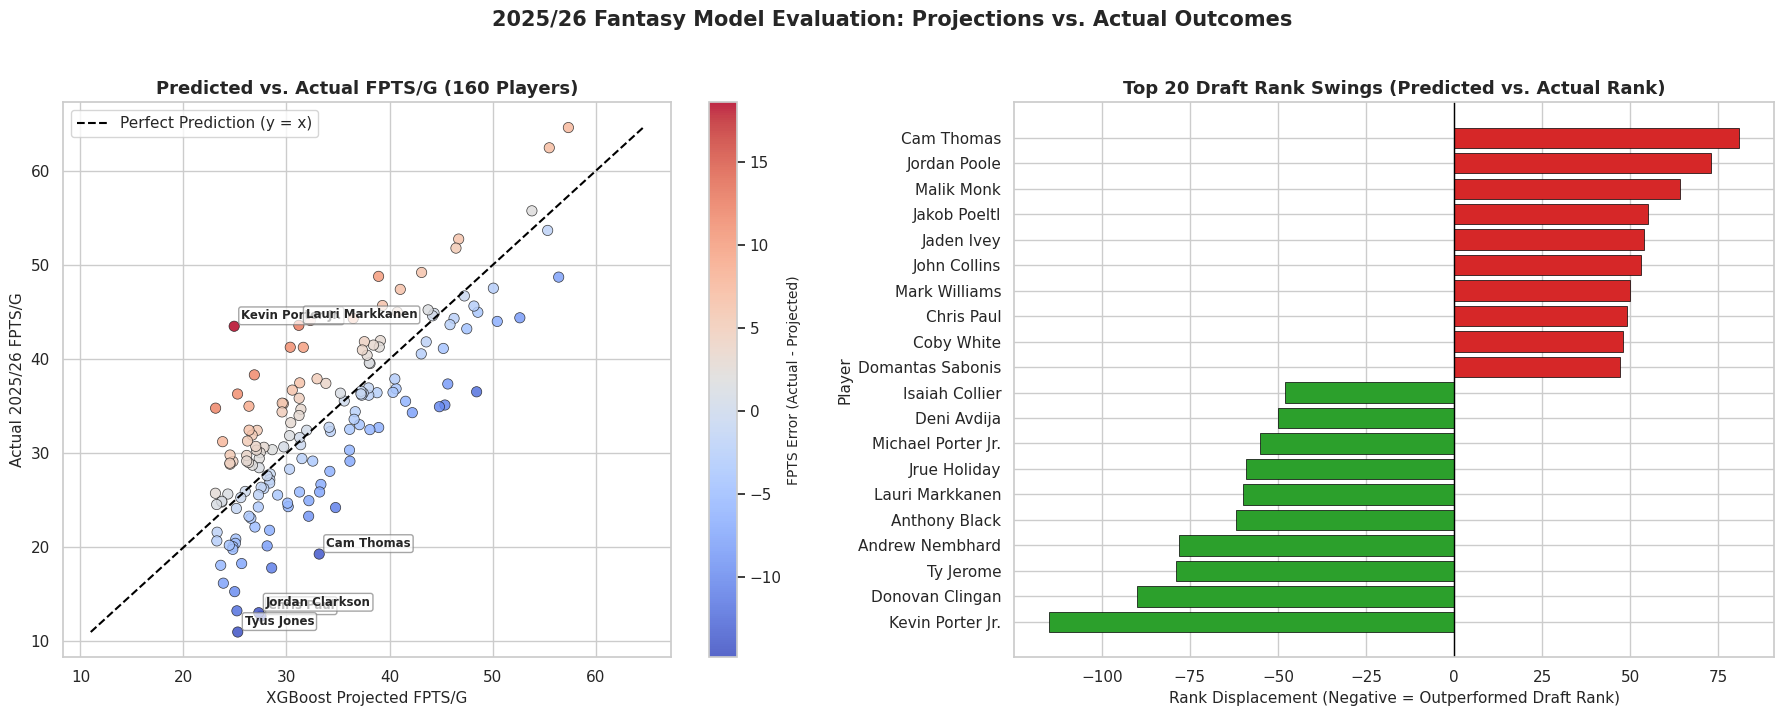

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Generate Comparison Dataset (Top 160 Players)

# Ensure backtest_df is sorted by projected VORP to isolate top 160 draft choices
plot_df = (
    backtest_df.sort_values("proj_vorp", ascending=False)
    .head(160)
    .reset_index(drop=True)
)

plot_df["predicted_rank"] = plot_df.index + 1
plot_df["actual_rank"] = (
    plot_df["actual_2025_fpts_pg"]
    .rank(ascending=False, method="min")
    .astype(int)
)
plot_df["rank_error"] = plot_df["actual_rank"] - plot_df["predicted_rank"]
plot_df["abs_fpts_error"] = (
    plot_df["actual_2025_fpts_pg"] - plot_df["proj_2025_fpts_pg"]
)

# Construct 2-Subplot Comparison Figure

sns.set_theme(style="whitegrid", font="DejaVu Sans")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graph 1: Predicted vs. Actual FPTS/G (Scatter Plot)

scatter = axes[0].scatter(
    plot_df["proj_2025_fpts_pg"],
    plot_df["actual_2025_fpts_pg"],
    c=plot_df["abs_fpts_error"],
    cmap="coolwarm",
    s=55,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.5,
)

# Ideal Reference Line (y = x)
min_val = min(
    plot_df["proj_2025_fpts_pg"].min(), plot_df["actual_2025_fpts_pg"].min()
)
max_val = max(
    plot_df["proj_2025_fpts_pg"].max(), plot_df["actual_2025_fpts_pg"].max()
)
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Perfect Prediction (y = x)",
)

# Label key extreme outliers
top_outliers = plot_df.reindex(
    plot_df["abs_fpts_error"].abs().sort_values(ascending=False).index
).head(6)

for _, row in top_outliers.iterrows():
    axes[0].annotate(
        row["player_name"],
        (row["proj_2025_fpts_pg"], row["actual_2025_fpts_pg"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7
        ),
    )

axes[0].set_title(
    "Predicted vs. Actual FPTS/G (160 Players)", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("XGBoost Projected FPTS/G", fontsize=11)
axes[0].set_ylabel("Actual 2025/26 FPTS/G", fontsize=11)
axes[0].legend(loc="upper left")
cbar = fig.colorbar(scatter, ax=axes[0])
cbar.set_label("FPTS Error (Actual - Projected)", fontsize=10)


# Graph 2: Top 20 Biggest Rank Swings (Bar Chart)

top_swings = plot_df.reindex(
    plot_df["rank_error"].abs().sort_values(ascending=False).index
).head(20)
top_swings = top_swings.sort_values("rank_error", ascending=True)

colors = ["#2ca02c" if x < 0 else "#d62728" for x in top_swings["rank_error"]]

axes[1].barh(
    top_swings["player_name"],
    top_swings["rank_error"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)
axes[1].axvline(0, color="black", linestyle="-", linewidth=1)
axes[1].set_title(
    "Top 20 Draft Rank Swings (Predicted vs. Actual Rank)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel(
    "Rank Displacement (Negative = Outperformed Draft Rank)", fontsize=11
)
axes[1].set_ylabel("Player", fontsize=11)

plt.suptitle(
    "2025/26 Fantasy Model Evaluation: Projections vs. Actual Outcomes",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()